# Tester le perceptron

En haut a droite, choisir le kernel **.venv (Python 3.12.7)**, puis cliquer sur **Run All / Tout executer**, ou executer les cellules dans l'ordre avec leur bouton de lecture.

Ce notebook importe la classe de `perceptron.py`


In [1]:
import sys
import numpy as np
from perceptron import Perceptron

print("Python :", sys.executable)


Python : c:\Users\User\Documents\projet la plateforme\Perceptron\building-perceptron\.venv\Scripts\python.exe


## 2. Preparer les donnees et entrainer

On apprend la porte logique **AND** : la sortie vaut 1 uniquement si les deux entrees valent 1.

`X` contient une ligne par exemple et une colonne par caracteristique. `y` contient une etiquette 0 ou 1 par exemple. `fit(X, y)` ajuste les poids et le biais. `errors_` enregistre le nombre d'erreurs pendant chaque epoque.

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

print("Entrees :\n", X)
print("Sorties attendues :", y)
print("Dimensions de X :", X.shape, "et de y :", y.shape)

model = Perceptron(learning_rate=0.1, n_epochs=20)
model.fit(X, y)

print("Poids :", model.weights)
print("Biais :", model.bias)
print("Erreurs par epoque :", model.errors_)
print("Predictions :", model.predict(X))

Entrees :
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Sorties attendues : [0 0 0 1]
Dimensions de X : (4, 2) et de y : (4,)
Poids : [0.2 0.1]
Biais : -0.20000000000000004
Erreurs par epoque : [2, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Predictions : [0 0 0 1]


## 3. Verifier les predictions

`predict(X)` renvoie une etiquette par ligne. Les assertions ci-dessous doivent passer sans erreur.

On mesure ici la precision sur les donnees d'entrainement : c'est un test de fonctionnement, pas une evaluation de generalisation. Pour un vrai dataset, il faudra separer les donnees d'entrainement et de test.

Un perceptron simple peut apprendre AND, mais pas XOR, car XOR n'est pas lineairement separable.

In [3]:
predictions = model.predict(X) # Faire des predictions sur les donnees d'entrainement
accuracy = float(np.mean(predictions == y)) # Calculer la precision sur les donnees d'entrainement

print("Predictions :", predictions)
print("Sorties attendues :", y)
print(f"Precision sur l'entrainement : {accuracy:.0%}")

assert predictions.shape == y.shape # Verifier que les dimensions des predictions correspondent a celles des sorties attendues
np.testing.assert_array_equal(predictions, y) # Verifier que les predictions correspondent aux sorties attendues
assert model.errors_[-1] == 0 # Verifier qu'il n'y a pas d'erreurs a la derniere epoque
print("Test AND reussi.")

new_examples = np.array([[1, 1], [0, 1]]) # Nouvelles entrees a predire
new_predictions = model.predict(new_examples) # Faire des predictions sur les nouvelles entrees
np.testing.assert_array_equal(new_predictions, np.array([1, 0])) # Verifier que les predictions sur les nouvelles entrees sont correctes    
print("Entrees a predire :\n", new_examples)
print("Predictions :", new_predictions)

Predictions : [0 0 0 1]
Sorties attendues : [0 0 0 1]
Precision sur l'entrainement : 100%
Test AND reussi.
Entrees a predire :
 [[1 1]
 [0 1]]
Predictions : [1 0]


## 4. XOR : comprendre une limite du perceptron

XOR signifie « l'une OU l'autre des entrees, mais pas les deux ». Contrairement a AND, XOR vaut 1 lorsque les deux valeurs sont differentes.

| Premiere entree | Deuxieme entree | Reponse XOR |
| --- | --- | --- |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Chaque ligne reste un exemple avec deux caracteristiques. La sortie reste une etiquette unique. On ne change pas la forme des donnees : on change la regle a apprendre.

### Pourquoi une droite ne suffit pas

Le score est $s = w_1 x_1 + w_2 x_2 + b$. `predict` repond 1 si $s \geq 0$, sinon 0. La frontiere entre les decisions est donc la droite $w_1 x_1 + w_2 x_2 + b = 0$.

Pour XOR, les points de classe 0 occupent deux coins opposes du carre, et ceux de classe 1 les deux autres. Aucune droite ne peut placer tous les 0 d'un cote et tous les 1 de l'autre : les classes ne sont pas **lineairement separables**. Plus d'epoques ne change pas cette limite. Cela ne signifie pas que NumPy est en panne.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from perceptron import Perceptron

xor_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_reference = np.array([0, 1, 1, 0])
xor_targets = xor_reference
np.testing.assert_array_equal(xor_targets, xor_reference)

xor_epochs_exercice = None
xor_epochs = 30 if xor_epochs_exercice is None else int(xor_epochs_exercice)
assert xor_epochs > 0
xor_model = Perceptron(learning_rate=0.1, n_epochs=xor_epochs).fit(xor_inputs, xor_targets)
xor_predictions = xor_model.predict(xor_inputs)

for example, expected, predicted in zip(xor_inputs, xor_targets, xor_predictions):
    print(f"Entree {example.tolist()} : attendu={expected}, predit={predicted}")

xor_final_errors = int(np.count_nonzero(xor_predictions != xor_targets))
print("Erreurs finales :", xor_final_errors, "sur 4")
print("Erreurs pendant chaque epoque :", xor_model.errors_)
assert xor_predictions.shape == (4,)
assert xor_final_errors > 0, "Un perceptron lineaire ne peut pas resoudre XOR."

Entree [0, 0] : attendu=0, predit=1
Entree [0, 1] : attendu=1, predit=1
Entree [1, 0] : attendu=1, predit=0
Entree [1, 1] : attendu=0, predit=0
Erreurs finales : 2 sur 4
Erreurs pendant chaque epoque : [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


### Voir XOR et sa droite de decision

Sur le graphique, chaque point represente une ligne de `xor_inputs`. Sa couleur indique la **vraie classe**, pas la prediction. La droite noire est la frontiere apprise : elle ne parvient pas a separer les deux couleurs.

Pour tracer cette droite, si $w_2 \neq 0$, on isole la deuxieme coordonnee :

$$x_2 = -\frac{w_1 x_1 + b}{w_2}.$$

Si $w_2 = 0$ et $w_1 \neq 0$, la droite est verticale : $x_1 = -b/w_1$. Si les deux poids sont nuls, il n'y a pas de droite definie ; on l'indique au lieu de diviser par zero.

Le graphique de droite montre `errors_` : les erreurs faites **pendant** chaque passage sur les exemples, avec des poids qui evoluent. Ce n'est pas le nombre d'erreurs du modele final. Le test precedent peut donc afficher 4 erreurs pendant une epoque et seulement 2 erreurs finales.

**Apres observation :**

- Les deux points de classe 1 se trouvent : Au opposé des deux points de classe 0
- La droite classe mal les entrees : Elle ne peut pas separer correctement les points de classe 1 et 0.
- La courbe atteint-elle durablement zero ? non 
- Mon explication de l'echec sur XOR : un perceptron linéaire ne peut separer correctement les classes 1 et 0 simultanement.

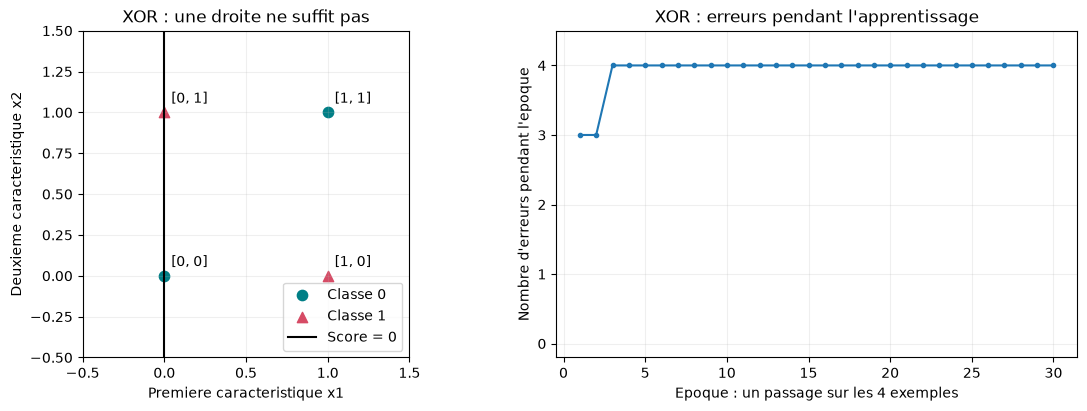

In [5]:
def plot_decision(axis, inputs, targets, trained_model):
    for label, color, marker in [(0, "#007f86", "o"), (1, "#d64b65", "^")]:
        points = inputs[targets == label]
        axis.scatter(points[:, 0], points[:, 1], c=color, marker=marker,
                     label=f"Classe {label}", s=55)
    lower = inputs.min(axis=0) - 0.5
    upper = inputs.max(axis=0) + 0.5
    first_weight, second_weight = trained_model.weights
    if second_weight != 0:
        horizontal = np.linspace(lower[0], upper[0], 200)
        vertical = -(first_weight * horizontal + trained_model.bias) / second_weight
        axis.plot(horizontal, vertical, color="black", label="Score = 0")
    elif first_weight != 0:
        axis.axvline(-trained_model.bias / first_weight, color="black", label="Score = 0")
    else:
        axis.text(0.05, 0.95, "Poids nuls : pas de droite", transform=axis.transAxes, va="top")
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])
    axis.set_xlabel("Premiere caracteristique x1")
    axis.set_ylabel("Deuxieme caracteristique x2")
    axis.legend()
    axis.grid(alpha=0.2)

xor_figure, xor_axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_decision(xor_axes[0], xor_inputs, xor_targets, xor_model)
xor_axes[0].set_title("XOR : une droite ne suffit pas")
xor_axes[0].set_aspect("equal", adjustable="box")
for example in xor_inputs:
    xor_axes[0].annotate(str(example.tolist()), example, xytext=(5, 7), textcoords="offset points")
xor_axes[1].plot(np.arange(1, xor_epochs + 1), xor_model.errors_, marker="o", markersize=3)
xor_axes[1].set_title("XOR : erreurs pendant l'apprentissage")
xor_axes[1].set_xlabel("Epoque : un passage sur les 4 exemples")
xor_axes[1].set_ylabel("Nombre d'erreurs pendant l'epoque")
xor_axes[1].set_ylim(-0.2, 4.5)
xor_axes[1].grid(alpha=0.2)
plt.show()

## 5. Donnees factices aleatoires avec NumPy

Nous fabriquons deux nuages : un autour de `[-1, 0]` (classe 0), l'autre autour de `[1, 0]` (classe 1). Chaque point recoit un petit deplacement aleatoire sur ses deux coordonnees.

La **dispersion** est l'amplitude maximale du deplacement. Avec 0.8, les nuages sont separes horizontalement : une droite peut les separer. Avec 1.8, ils peuvent se chevaucher, et atteindre zero erreur n'est plus garanti.

La **graine** fixe le tirage aleatoire : garder 42 permet de comparer les experiences sur exactement les memes points. Nous melangeons les exemples pour ne pas presenter toute une classe avant l'autre.

Nous reservons 25 % des points au **test**. `fit` ne voit que les points d'entrainement. Ensuite `predict` peut recevoir les points de test : chaque ligne a toujours deux colonnes, mais le nombre de lignes peut changer.

### A completer dans le code

- `spread_exercice` : remplace `None` par `0.8`, puis essaie `1.8`.
- `random_eta_exercice` : remplace `None` par un taux positif, par exemple `0.1`.
- `test_predictions_exercice` : remplace `None` par l'appel qui predit sur `random_test_inputs`. Indice : `random_model.predict(...)`.

Les valeurs de secours rendent la cellule executable avant que tu aies termine. Reexecute cette cellule puis les suivantes apres une modification.

**Avant execution :** si les deux nuages se chevauchent, je m'attends a __________.

Dimensions entrainement : (90, 2)
Dimensions test : (30, 2)
Accuracy entrainement : 100.0%
Accuracy test : 100.0%


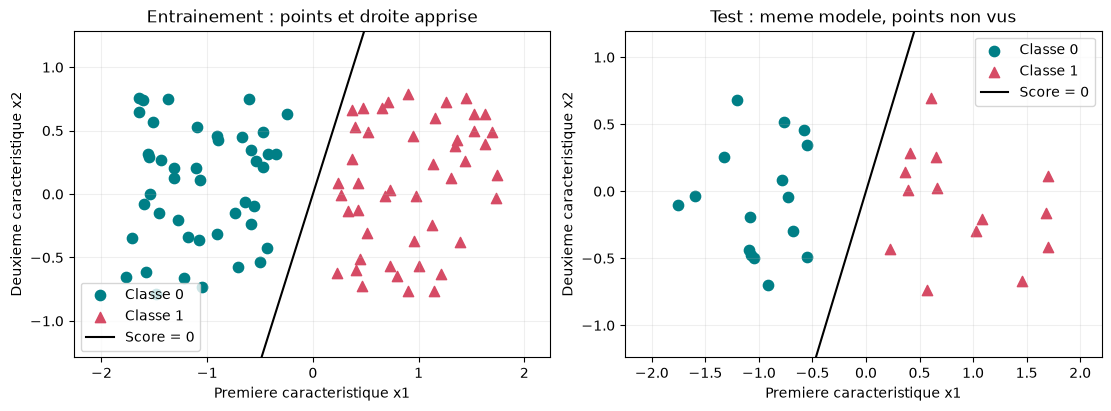

In [6]:
spread_exercice = 0.8 # Dispersion des points pour l'exercice
random_eta_exercice = 0.1 # Taux d'apprentissage pour l'exercice
spread = float(spread_exercice)
random_eta =  float(random_eta_exercice)
assert spread > 0 and random_eta > 0 # Vérification que les paramètres sont positifs

random_generator = np.random.default_rng(42) # Générateur de nombres aléatoires avec une graine fixe pour la reproductibilité
points_per_class = 60 # Nombre de points par classe
class_zero = np.array([-1.0, 0.0]) + random_generator.uniform(-spread, spread, (points_per_class, 2))
class_one = np.array([1.0, 0.0]) + random_generator.uniform(-spread, spread, (points_per_class, 2))
random_inputs = np.vstack([class_zero, class_one])
random_targets = np.concatenate([np.zeros(points_per_class, dtype=int), np.ones(points_per_class, dtype=int)])
shuffled_indices = random_generator.permutation(len(random_targets))
split_index = int(0.75 * len(random_targets))
train_indices = shuffled_indices[:split_index]
test_indices = shuffled_indices[split_index:]
random_train_inputs, random_train_targets = random_inputs[train_indices], random_targets[train_indices]
random_test_inputs, random_test_targets = random_inputs[test_indices], random_targets[test_indices]
assert not np.intersect1d(train_indices, test_indices).size # Vérification qu'il n'y a pas de chevauchement entre les indices d'entrainement et de test

random_model = Perceptron(learning_rate=random_eta, n_epochs=40)  # Initialisation du perceptron avec le taux d'apprentissage et le nombre d'époques spécifiés
random_model.fit(random_train_inputs, random_train_targets) # Entraînement du perceptron sur les données d'entrainement
test_predictions_exercice = random_model.predict(random_test_inputs) # Predictions pour l'exercice
test_predictions = np.asarray(test_predictions_exercice)
assert test_predictions.shape == random_test_targets.shape
np.testing.assert_array_equal(test_predictions, random_model.predict(random_test_inputs))
print("Dimensions entrainement :", random_train_inputs.shape)
print("Dimensions test :", random_test_inputs.shape)
print(f"Accuracy entrainement : {np.mean(random_model.predict(random_train_inputs) == random_train_targets):.1%}")
print(f"Accuracy test : {np.mean(test_predictions == random_test_targets):.1%}")

random_figure, random_axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_decision(random_axes[0], random_train_inputs, random_train_targets, random_model)
random_axes[0].set_title("Entrainement : points et droite apprise")
plot_decision(random_axes[1], random_test_inputs, random_test_targets, random_model)
random_axes[1].set_title("Test : meme modele, points non vus")
plt.show()

## 6. Courbes erreurs / epoques : comparer trois valeurs de eta

**Une epoque** est un passage sur tous les exemples d'entrainement. L'axe horizontal compte les epoques a partir de 1. L'axe vertical compte les erreurs pendant chaque passage. Une courbe a zero indique qu'aucun exemple n'a provoque de correction pendant cette epoque.

**Eta**, note $\eta$, est le taux d'apprentissage (`learning_rate`).

**Avant execution :**

- Sur XOR, je pense que changer eta permettra / ne permettra pas de tout apprendre :ca ne va rien changer car le perceptron qui est linéaire ne peut pas apprendre XOR.
- Sur les nuages separes, je m'attends a une courbe qui : decroit rapidement vers zero, car le perceptron lineaire peut apprendre a separer correctement les points.
- Si les courbes se superposent, je l'expliquerai par : le fait que les eta sont juste modifiés sur leur nombre de calcul, mais la frequence des corrections restent les memes.

eta=0.01 | accuracy test nuages=100.0% | erreurs finales XOR=2/4
  Nuages : poids / eta = [ 0.9003 -0.3401] ; biais / eta = 0.0
eta=0.1 | accuracy test nuages=100.0% | erreurs finales XOR=2/4
  Nuages : poids / eta = [ 0.9003 -0.3401] ; biais / eta = 0.0
eta=1.0 | accuracy test nuages=100.0% | erreurs finales XOR=2/4
  Nuages : poids / eta = [ 0.9003 -0.3401] ; biais / eta = 0.0


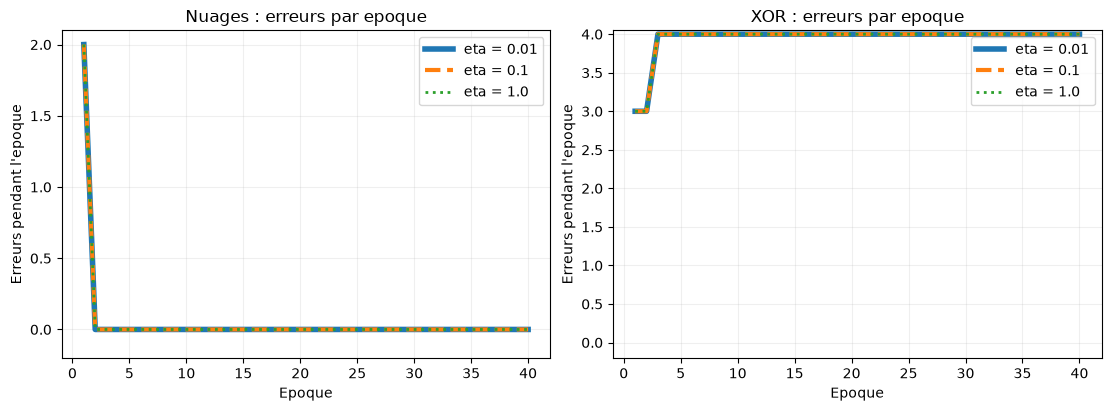

Nuages : courbes identiques pour les taux testes ? True
XOR : courbes identiques pour les taux testes ? True


In [7]:
eta_values_exercice = [0.01, 0.1, 1.0]
comparison_epochs_exercice = 40
eta_values =  list(eta_values_exercice)
comparison_epochs = int(comparison_epochs_exercice)
assert 2 <= len(eta_values) <= 3 # On s'assure qu'on a entre 2 et 3 valeurs de eta
assert len(set(eta_values)) == len(eta_values)  # On s'assure qu'il n'y a pas de doublons dans les valeurs de eta
assert all(np.isfinite(eta) and eta > 0 for eta in eta_values)  # On s'assure que toutes les valeurs de eta sont finies et positives
assert comparison_epochs > 0  # On s'assure que le nombre d'epochs est positif

comparison_figure, comparison_axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
comparison_histories = {"Nuages": [], "XOR": []}
line_styles = ["-", "--", ":"]
epoch_numbers = np.arange(1, comparison_epochs + 1)

for eta_index, eta in enumerate(eta_values):
    cloud_model = Perceptron(learning_rate=eta, n_epochs=comparison_epochs)
    cloud_model.fit(random_train_inputs, random_train_targets)
    comparison_xor_model = Perceptron(learning_rate=eta, n_epochs=comparison_epochs)
    comparison_xor_model.fit(xor_inputs, xor_targets)
    comparison_histories["Nuages"].append(cloud_model.errors_)
    comparison_histories["XOR"].append(comparison_xor_model.errors_)
    comparison_axes[0].plot(epoch_numbers, cloud_model.errors_, linestyle=line_styles[eta_index],
                            linewidth=4 - eta_index, label=f"eta = {eta}")
    comparison_axes[1].plot(epoch_numbers, comparison_xor_model.errors_, linestyle=line_styles[eta_index],
                            linewidth=4 - eta_index, label=f"eta = {eta}")
    cloud_test_accuracy = float(np.mean(cloud_model.predict(random_test_inputs) == random_test_targets))
    comparison_xor_errors = int(np.count_nonzero(comparison_xor_model.predict(xor_inputs) != xor_targets))
    assert comparison_xor_errors > 0
    assert len(cloud_model.errors_) == comparison_epochs
    print(f"eta={eta} | accuracy test nuages={cloud_test_accuracy:.1%} | erreurs finales XOR={comparison_xor_errors}/4")
    print("  Nuages : poids / eta =", np.round(cloud_model.weights / eta, 4),
          "; biais / eta =", round(float(cloud_model.bias / eta), 4))

for axis, title in zip(comparison_axes, ["Nuages : erreurs par epoque", "XOR : erreurs par epoque"]):
    axis.set_title(title)
    axis.set_xlabel("Epoque")
    axis.set_ylabel("Erreurs pendant l'epoque")
    axis.set_ylim(bottom=-0.2)
    axis.legend()
    axis.grid(alpha=0.2)
plt.show()

for dataset_name, histories in comparison_histories.items():
    identical = all(np.array_equal(histories[0], history) for history in histories[1:])
    print(f"{dataset_name} : courbes identiques pour les taux testes ? {identical}")

## 7. Ton bilan : montrer les limites du perceptron

**But de l'exercice XOR : constater et expliquer son echec, pas le faire reussir.** L'assertion `xor_final_errors > 0` valide ici le resultat attendu de l'experience. Ce n'est pas une preuve generale a elle seule : l'explication geometrique donne la raison pour laquelle aucune droite ne peut resoudre XOR.

Complete les phrases avec tes observations, sans seulement recopier les scores :

1. Une ligne de `X` represente les entrees d'un exemple et ses deux colonnes representent x1 et x2 qui sont les caracteristiques de cet exemple.
2. `y` contient la prediction attendue pour chaque exemple, tandis que `predict(X)` calcule la prediction du perceptron pour chaque exemple.
3. Deux valeurs deviennent un score unique parce que le perceptron calcule une combinaison lineaire de ces valeurs.
4. Pour XOR, les points de meme classe sont à des coins opposés du carré. Une seule droite ne peut donc pas permettre de les separer correctement car xor a besoin que la frontiere soit non lineaire( une des deux valeurs de sortie doit etre égale à 1 et l'autre à 0).
5. Avec les trois valeurs de eta, les erreurs finales sur XOR sont toujours supérieures à zéro. Augmenter les epoques ne resout pas le probleme parce que XOR ne peut pas être séparé linéairement.
6. Avec les nuages separes, la courbe atteint zero a l'epoque 1. L'accuracy sur les points de test est 100%.
7. Les courbes des trois eta se superposent ici parce que les poids sont initialises a 0 et que multiplier un score par un nombre positif ne change pas le signe de score, ni sa frequence de variation.
8. `errors_` compte les erreurs de la machione pendant l'entrainement, tandis que comparer les predictions finales avec `y` compte les erreurs sur l'ensemble des exemples apres l'entrainement.


Pour apprendre XOR, il faudrait changer la representation des entrees ou utiliser un modele non lineaire, par exemple un reseau avec une couche cachee. Ce serait un autre exercice : ici, on conserve le perceptron simple pour rendre sa limite visible.